Here, we scan and plot the Fano factors with omega_0 on the y-axis and u on the x-axis. and consider three values of zeta = 0.5, 1.0, 2.0.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import math
import os
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from matplotlib.ticker import FixedLocator
import time

import gaussian_crossings.formula as formula
import gaussian_crossings.process as process


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    # "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "pdf.fonttype": 3,
})


In [11]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"

ModelClass = formula.GaussianUpCrossings
mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

# Labels
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$ (Fano Factor)'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$ (Fano Factor)'
else:
    fano_label = r'$\mathrm{F}$ (Fano Factor)'

In [12]:
# Set simulation parameters
T = 20.0
temp = 1.0  # Fixed temperature
zeta_values = [0.5, 1.0, 2.0]

In [13]:
# Parameter grids
num_points_omega = 20
omega0_vals = torch.linspace(0.5, 10.0, num_points_omega)

num_points_u = 20
u_vals = torch.linspace(0.0, 2.0, num_points_u)

# Storage for results
mean_rates_all = {}
fano_factors_all = {}

In [14]:
# Compute function for parallel processing
def compute_point(i, j, current_omega0, current_u, temp, zeta, ModelClass, mean_rate_method, fano_method):
    """Calculates mean rate and Fano factor for a single parameter combination."""
    try:
        omega0 = current_omega0.item() if isinstance(current_omega0, torch.Tensor) else current_omega0
        u = current_u
        model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)
        mr = getattr(model, mean_rate_method)()
        ff = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)
        return i, j, mr, ff
    except Exception as e:
        print(f"Error in worker for i={i}, j={j}: {e}")
        return i, j, float('nan'), float('nan')

# Loop through zeta values
for zeta in zeta_values:
    print(f"\nProcessing zeta = {zeta}")
    
    mean_rates = torch.zeros(num_points_omega, num_points_u)
    fano_factors = torch.zeros(num_points_omega, num_points_u)
    
    # Prepare tasks
    tasks = [(i, j, omega0_vals[i], u_vals[j]) for i in range(num_points_omega) for j in range(num_points_u)]
    
    print(f"Starting parallel computation for {len(tasks)} points...")
    start_time = time.time() 
    
    # Execute in parallel
    results = Parallel(n_jobs=-1, verbose=1)(
        delayed(compute_point)(
            task[0], task[1], task[2], task[3], 
            temp, zeta, ModelClass, mean_rate_method, fano_method 
        ) for task in tasks
    )
    
    end_time = time.time() 
    print(f"Parallel computation finished in {end_time - start_time:.2f} seconds.")
    
    # Process results
    for res in results:
        if res is not None:
            i, j, mr, ff = res
            mean_rates[i, j] = mr
            fano_factors[i, j] = ff
        else:
            print("Warning: A worker task returned None.")
    
    # Store results
    mean_rates_all[zeta] = mean_rates
    fano_factors_all[zeta] = fano_factors


Processing zeta = 0.5
Starting parallel computation for 400 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 116 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Parallel computation finished in 1.29 seconds.

Processing zeta = 1.0
Starting parallel computation for 400 points...


[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Parallel computation finished in 0.88 seconds.

Processing zeta = 2.0
Starting parallel computation for 400 points...


[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    0.6s


Parallel computation finished in 0.99 seconds.


[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    1.0s finished


In [15]:
# Plotting parameters
axis_label_fontsize = 30
title_fontsize = 28
tick_label_fontsize = 28
num_x_ticks = 5
num_y_ticks = 5
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps
cmap_diverging = 'PRGn'

In [16]:
# Calculate global color scale
all_log_fano_values_list = []
for zeta_val in zeta_values:
    fano_data = fano_factors_all[zeta_val]
    fano_log = torch.log10(fano_data)
    all_log_fano_values_list.append(fano_log.cpu().numpy().flatten())

concatenated_logs = np.concatenate(all_log_fano_values_list)
global_log_min = np.nanmin(concatenated_logs)
global_log_max = np.nanmax(concatenated_logs)

# Create the global normalization
norm_global = mcolors.Normalize(vmin=global_log_min, vmax=global_log_max)

if (global_log_max - global_log_min) == 0:
    p_val_global = 0.5
else:
    p_val_global = (0 - global_log_min) / (global_log_max - global_log_min)
p_val_global = np.clip(p_val_global, 1e-6, 1.0 - 1e-6)

base_cmap_obj_global = plt.get_cmap(cmap_diverging)
color_for_log_min_global = base_cmap_obj_global(0.0)
color_for_one_global = base_cmap_obj_global(0.5)
color_for_log_max_global = base_cmap_obj_global(1.0)

segmented_colors_global = [
    (0.0, color_for_log_min_global),
    (p_val_global, color_for_one_global),
    (1.0, color_for_log_max_global)
]
cmap_global = mcolors.LinearSegmentedColormap.from_list(
    "custom_global_fano_cmap", segmented_colors_global
)

Saving figures to: ../../figures/damped_harmonic_oscillator/fano_factor_upcrossing_multiple_zeta_temp_1.00_omega_scan


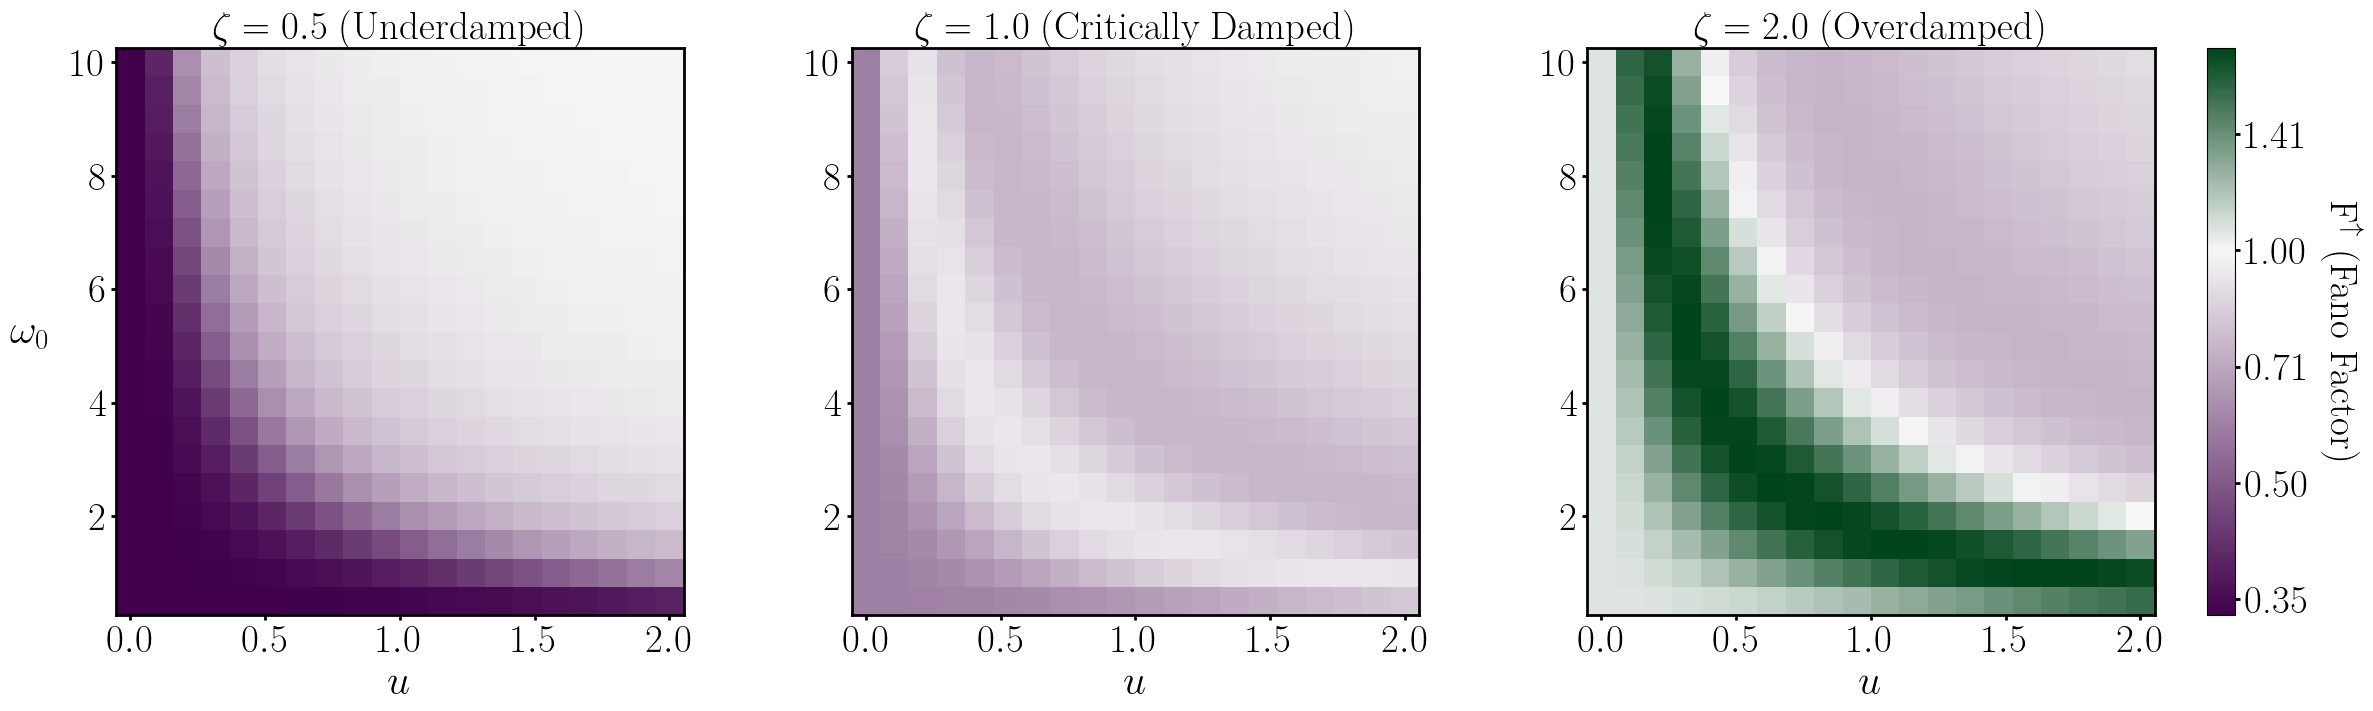

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

pc_ref = None

# Plot Fano factors for each zeta value
for idx, zeta in enumerate(zeta_values):
    fano_factors = fano_factors_all[zeta]
    fano_log = torch.log10(fano_factors)
    fano_log_np = fano_log.cpu().numpy()

    pc = axes[idx].pcolormesh(u_vals, omega0_vals, fano_log_np, shading='auto', cmap=cmap_global, norm=norm_global)
    axes[idx].set_box_aspect(1)
    if idx == (len(zeta_values) -1):
        pc_ref = pc

    axes[idx].set_xlabel(r'$u$', fontsize=axis_label_fontsize)
    if idx == 0:
        axes[idx].set_ylabel(r'$\omega_0$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30)

    # Set titles for subplots
    if idx == 0:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Underdamped)', fontsize=title_fontsize)
    elif idx == 1:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Critically Damped)', fontsize=title_fontsize)
    else:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Overdamped)', fontsize=title_fontsize)

    axes[idx].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
    axes[idx].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

    for spine in axes[idx].spines.values():
        spine.set_linewidth(spine_line_width)

cbar = fig.colorbar(
        pc_ref,
        ax=axes.ravel().tolist(),
        location="right",
        fraction=0.046, pad=0.02)
cbar.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_locs_fano_global = mticker.MaxNLocator(nbins=5).tick_values(global_log_min, global_log_max)
cbar.locator = FixedLocator(tick_locs_fano_global)
cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"{10**x:.2f}")
cbar.update_ticks()
cbar.set_label(fano_label, fontsize=tick_label_fontsize, rotation=270, labelpad=40)

# Save the figure
folder_loc = f'../../figures/damped_harmonic_oscillator/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'fano_factor_{crossing_type}_multiple_zeta_temp_{temp:.2f}_omega_scan'
file_save_path = os.path.join(folder_loc, file_name)

print(f"Saving figures to: {file_save_path}")
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()